In [2]:
from imblearn.over_sampling import SMOTE

In [4]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [5]:
#  Load dataset
df = pd.read_csv("clean_streetlight_dataset (2).csv")

df.head()

,timestamp,power_consumption (Watts),voltage_levels (Volts),current_fluctuations (Amperes),temperature (Celsius),environmental_conditions,current_fluctuations_env (Amperes),fault_type
0,07:53:23,106.18,238.52,6.127984,21.97,2,0.78,1
1,16:28:29,58.71,235.99,3.010000,24.16,0,0.10,0
2,19:17:46,195.49,234.97,1.060000,13.64,2,0.92,0
3,18:19:43,95.64,225.74,2.160000,15.82,2,3.06,0
4,08:26:19,116.02,213.66,2.480000,10.69,0,4.55,0


In [6]:
# Convert timestamp to useful feature
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour

df = df.drop('timestamp', axis=1)

C:\Users\Dell\AppData\Local\Temp\ipykernel_38956\3585276122.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


In [7]:
# Encode categorical column
le = LabelEncoder()

df['environmental_conditions'] = le.fit_transform(df['environmental_conditions'])

In [8]:
print("Class distribution BEFORE balancing:")
print(df['fault_type'].value_counts())

Class distribution BEFORE balancing:
fault_type
0    24111
1     1706
Name: count, dtype: int64


In [9]:
df_0 = df[df['fault_type'] == 0]
df_1 = df[df['fault_type'] == 1]


In [12]:
from sklearn.utils import resample
# Downsample class 0 to 12582
df_0_down = resample(df_0,
                     replace=False,
                     n_samples=12582,
                     random_state=42)

# Upsample class 1 to 13230
df_1_up = resample(df_1,
                   replace=True,
                   n_samples=13230,
                   random_state=42)


In [13]:
# Combine dataset
df_balanced = pd.concat([df_0_down, df_1_up])

In [14]:
df_balanced = df_balanced.sample(frac=1, random_state=42)

In [15]:
print(df_balanced['fault_type'].value_counts())

fault_type
1    13230
0    12582
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
X = df_balanced.drop('fault_type', axis=1)
y = df_balanced['fault_type']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y_pred = model.predict(X_test)

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8512492736780941

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      2556
           1       0.85      0.86      0.85      2607

    accuracy                           0.85      5163
   macro avg       0.85      0.85      0.85      5163
weighted avg       0.85      0.85      0.85      5163


Confusion Matrix:

[[2160  396]
 [ 372 2235]]


In [ ]:
#Logistic Regression was implemented to classify streetlight sensor data into operational and 
#faulty states. The model was trained using an 80-20 train-test split and evaluated using accuracy, 
#precision, recall, and F1-score. 


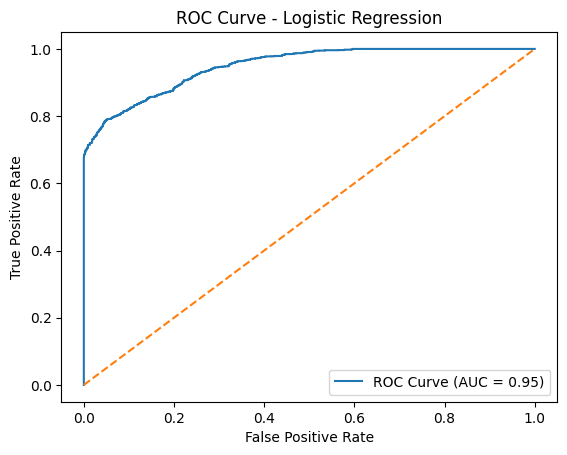

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions
y_prob = model.predict_proba(X_test)[:,1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % auc_score)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()